## **Table 5.1. Relevant dependencies for Chapter 5**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.display import display_pdf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from matplotlib.patches import Ellipse
from scipy.stats import gaussian_kde
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
import zipfile
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, \
roc_curve,  precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve, log_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

## **Figure 5.1: Linear Classification using Fisher's Linear Discriminant**

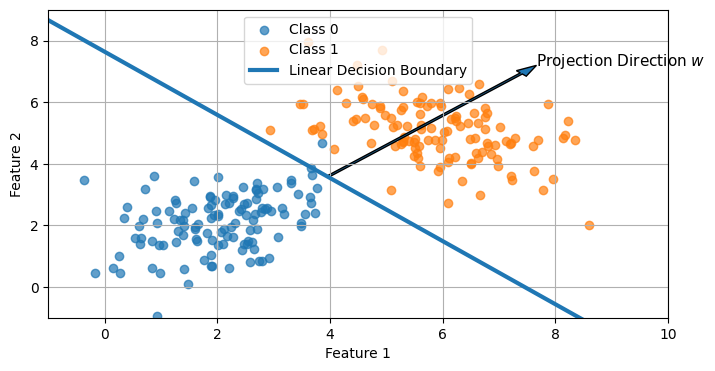

In [ ]:
np.random.seed(42)

# Class 0
mean0 = [2, 2]
cov0 = [[1.0, 0.5],
        [0.5, 1.0]]
X0 = np.random.multivariate_normal(mean0, cov0, 120)

# Class 1
mean1 = [6, 5]
cov1 = [[1.2, -0.3],
        [-0.3, 1.0]]
X1 = np.random.multivariate_normal(mean1, cov1, 120)

# Combine dataset
X = np.vstack([X0, X1])
y = np.array([0]*120 + [1]*120)

# Fisher Linear Discriminant
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Weight vector and intercept
w = lda.coef_[0]
b = lda.intercept_[0]

# Decision boundary
# w1*x + w2*y + b = 0
# => y = -(w1*x + b)/w2
x_vals = np.linspace(-1, 10, 200)
y_vals = -(w[0]*x_vals + b) / w[1]

plt.figure(figsize=(8,4))
plt.scatter(X0[:,0], X0[:,1],
            alpha=0.7,
            label='Class 0')

plt.scatter(X1[:,0], X1[:,1],
            alpha=0.7,
            label='Class 1')

# Decision boundary
plt.plot(x_vals, y_vals,
         linewidth=3,
         label='Linear Decision Boundary')

# Projection direction vector
center = np.mean(X, axis=0)

plt.arrow(center[0], center[1],
          w[0], w[1],
          width=0.05,
          head_width=0.25,
          length_includes_head=True)

plt.text(center[0] + w[0],
         center[1] + w[1],
         r'Projection Direction $w$',
         fontsize=11)
plt.title("Linear Classification using Fisher's Linear Discriminant",
           fontsize=14)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.xlim(-1, 10)
plt.ylim(-1, 9)

plt.legend()
plt.grid(True)

plt.show()

## **Figure 5.2: Geometric interpretation of Fisher’s Linear Discriminant showing within-class scatter, between-class separation, optimal projection direction, and projected class distributions**

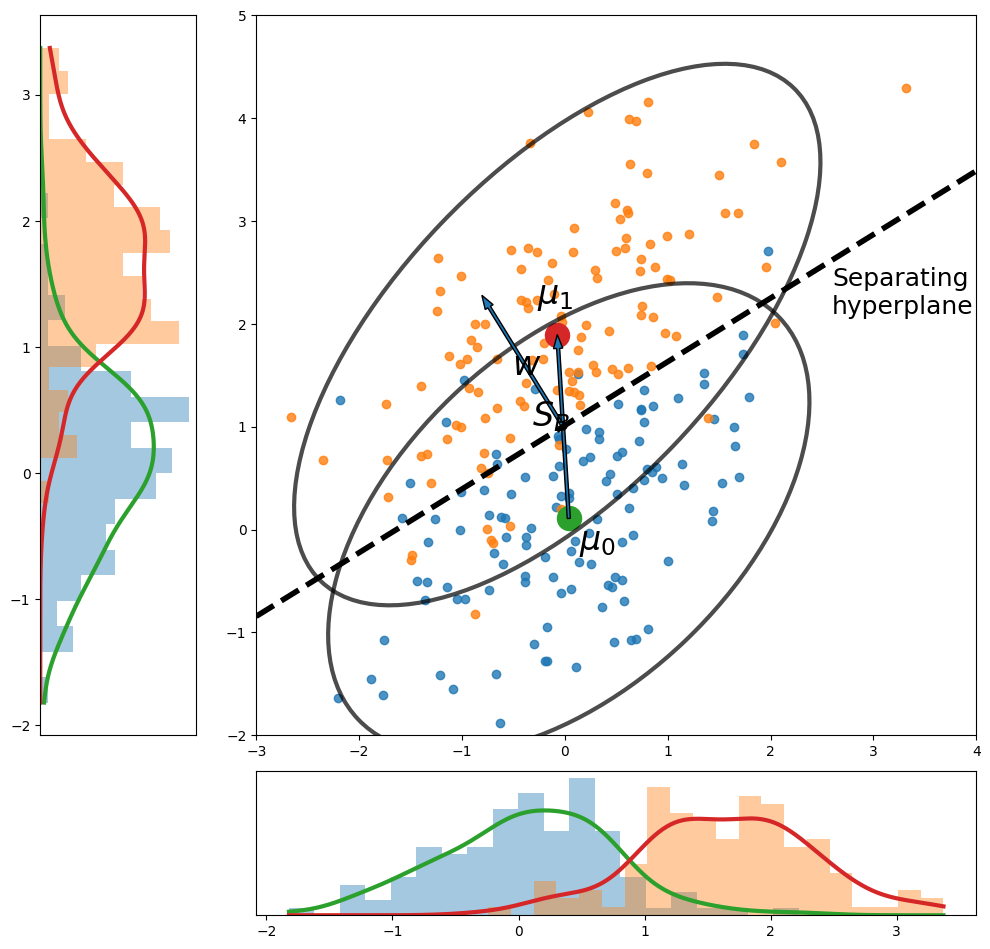

In [ ]:
np.random.seed(42)

mean0 = np.array([0, 0])
cov0 = np.array([[1.0, 0.6],
                 [0.6, 1.0]])

mean1 = np.array([0, 2])
cov1 = np.array([[1.0, 0.5],
                 [0.5, 1.0]])

X0 = np.random.multivariate_normal(mean0, cov0, 120)
X1 = np.random.multivariate_normal(mean1, cov1, 120)

# Fisher projection direction
mu0 = X0.mean(axis=0)
mu1 = X1.mean(axis=0)

S0 = np.cov(X0.T)
S1 = np.cov(X1.T)

SW = S0 + S1

w = np.linalg.inv(SW).dot(mu1 - mu0)
w = w / np.linalg.norm(w)

# Projection
proj0 = X0 @ w
proj1 = X1 @ w


fig = plt.figure(figsize=(12,12))

ax_main = plt.axes([0.2,0.2,0.6,0.6])
ax_bottom = plt.axes([0.2,0.05,0.6,0.12])
ax_left = plt.axes([0.02,0.2,0.13,0.6])

ax_main.scatter(X0[:,0], X0[:,1], alpha=0.8)
ax_main.scatter(X1[:,0], X1[:,1], alpha=0.8)

# Means
ax_main.scatter(*mu0, s=300)
ax_main.scatter(*mu1, s=300)

ax_main.text(mu0[0]+0.1, mu0[1]-0.3, r'$μ_0$', fontsize=24)
ax_main.text(mu1[0]-0.2, mu1[1]+0.3, r'$μ_1$', fontsize=24)

# Ellipses for within-class scatter
def draw_ellipse(ax, mean, cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:,order]

    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    width, height = 2 * np.sqrt(vals) * 2.5

    ellipse = Ellipse(xy=tuple(mean),
                      width=width,
                      height=height,
                      angle=theta,
                      fill=False,
                      lw=3,
                      alpha=0.7)

    ax.add_patch(ellipse)

draw_ellipse(ax_main, mu0, S0)
draw_ellipse(ax_main, mu1, S1)

# Between-class vector
ax_main.arrow(mu0[0],
              mu0[1],
              mu1[0]-mu0[0],
              mu1[1]-mu0[1],
              width=0.03,
              length_includes_head=True)

ax_main.text((mu0[0]+mu1[0])/2 -0.3,
             (mu0[1]+mu1[1])/2,
             r'$S_B$',
             fontsize=24)

# Projection vector
center = (mu0 + mu1)/2

ax_main.arrow(center[0],
              center[1],
              w[0]*1.5,
              w[1]*1.5,
              width=0.03,
              length_includes_head=True)

ax_main.text(center[0]-0.5,
             center[1]+0.5,
             r'$w$',
             fontsize=24)

# Decision boundary
x = np.linspace(-3,4,200)

slope = -w[0]/w[1]
intercept = center[1] - slope*center[0]

y = slope*x + intercept

ax_main.plot(x,y,'k--',lw=4)

ax_main.text(2.6,2.1,'Separating\nhyperplane',fontsize=18)

ax_main.set_xlim(-3,4)
ax_main.set_ylim(-2,5)

ax_main.set_title(
    "Fisher's Linear Discriminant: Geometric Interpretation",
    fontsize=20)


bins = 20

ax_bottom.hist(proj0,
               bins=bins,
               density=True,
               alpha=0.4)

ax_bottom.hist(proj1,
               bins=bins,
               density=True,
               alpha=0.4)

xgrid = np.linspace(min(proj0.min(), proj1.min()),
                    max(proj0.max(), proj1.max()),
                    500)

kde0 = gaussian_kde(proj0)
kde1 = gaussian_kde(proj1)

ax_bottom.plot(xgrid, kde0(xgrid), lw=3)
ax_bottom.plot(xgrid, kde1(xgrid), lw=3)

ax_bottom.set_yticks([])

ax_left.hist(proj0,
             bins=bins,
             density=True,
             orientation='horizontal',
             alpha=0.4)

ax_left.hist(proj1,
             bins=bins,
             density=True,
             orientation='horizontal',
             alpha=0.4)

ax_left.plot(kde0(xgrid), xgrid, lw=3)
ax_left.plot(kde1(xgrid), xgrid, lw=3)

ax_left.set_xticks([])

plt.show()

In [ ]:
# Kaggle library
!pip install kaggle
!mkdir -p ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download christianpartal/credit-card-data

In [3]:
zip_file_name = 'credit-card-data.zip'
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')
print(os.listdir('.'))


['.config', 'credit-card-data.zip', 'credit_card_data.csv', 'sample_data']


## **Code Block 5.1: Data ingestion**

In [5]:
df = pd.read_csv('credit_card_data.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## **Figure 5.4: Basic exploratory data analysis (EDA) results**

In [ ]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass distribution:\n", df['Class'].value_counts())
print(f"Fraud cases: {df['Class'].sum():,} out of {len(df):,} ({df['Class'].mean()*100:.4f}%)")

Dataset shape: (284807, 31)

Missing values:
 0

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64
Fraud cases: 492 out of 284,807 (0.1727%)


In [ ]:
print(df['Class'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## **Code Block 5.2: Pearson’s correlation analysis**

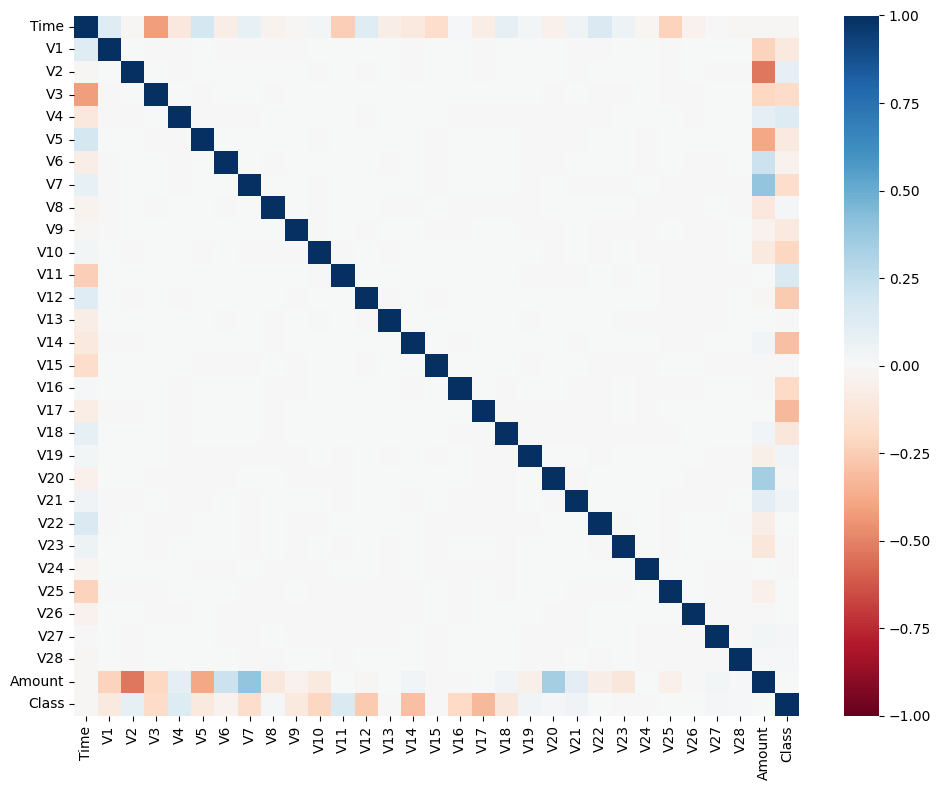

In [ ]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu', vmin=-1)

plt.tight_layout()
plt.show()

 ## **Code Block 5.3: Feature Engineering, Scaling, and Stratified Train-Test Split**

In [6]:
# All columns except Class are features
X = df.drop('Class', axis=1)
y = df['Class']
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Standardize Amount
scaler_amount = StandardScaler()
X['Amount_scaled'] = scaler_amount.fit_transform(X[['Amount']])

# Standardize Time
scaler_time = StandardScaler()
X['Time_scaled'] = scaler_time.fit_transform(X[['Time']])
X = X.drop('Time', axis=1)

# Train-Test Split (Stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Fraud in training: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Features (X) shape: (284807, 30)
Target (y) shape: (284807,)

Training set size: 199364
Test set size: 85443
Fraud in training: 344 (0.1725%)
Fraud in test: 148 (0.1732%)


## **Code Block 5.4: Applying Linear Discriminant Analysis**

In [7]:
lda = LinearDiscriminantAnalysis(
    n_components=1,
    solver='svd',
    store_covariance=True,
    priors=[0.5, 0.5]).fit(X_train, y_train)

# Transform the data to LDA space
X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

print(f"\nOriginal feature space: {X_train.shape[1]} dimensions")
print(f"LDA-transformed space: {X_train_lda.shape[1]} dimension")


Original feature space: 31 dimensions
LDA-transformed space: 1 dimension


## **Code block 5.5: Summary of the model's performance. It includes precision, recall, F1-score, and support for each class (Normal and Fraud), as well as overall accuracy**

In [8]:
y_pred = lda.predict(X_test)
y_pred_proba = lda.predict_proba(X_test)[:, 1]

print("LDA CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# PR-AUC Score
prauc_score_lda = average_precision_score(y_test, y_pred_proba)
print(f"\nPR-AUC Score: {prauc_score_lda:.4f}")

LDA CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.83      0.74      0.78       148

    accuracy                           1.00     85443
   macro avg       0.92      0.87      0.89     85443
weighted avg       1.00      1.00      1.00     85443


Confusion Matrix:
[[85273    22]
 [   39   109]]

PR-AUC Score: 0.6758


## **Code block 5.6: Calculate class weights**

In [ ]:
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train)
weights_dict = dict(zip(np.unique(y_train), class_weights))
print(f"\nClass weights: {weights_dict}")


Class weights: {np.int64(0): np.float64(0.5008642347502763), np.int64(1): np.float64(289.7732558139535)}


## **Code block 5.7: Cross validation used to evaluate the generalization ability of a model**

In [ ]:
# Number of folds for cross-validation
N_SPLITS = 5

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

## **Code block 5.8: Logistic Regression with class weights to handle imbalance**

In [ ]:
log_reg = LogisticRegression(
    penalty = 'l2',
    solver='liblinear',
    class_weight=weights_dict,
    random_state=42)

log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Predict class probabilities
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_log_reg, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(cm_log_reg)

# PR-AUC Score
prauc_score_log_reg = average_precision_score(y_test, y_pred_proba_log_reg)
print(f"\nPR-AUC Score (Logistic Regression): {prauc_score_log_reg:.4f}")

print("\n")
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"LDA PR-AUC: {prauc_score_lda:.4f}")
print(f"Logistic Regression PR-AUC: {prauc_score_log_reg:.4f}")

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     85295
       Fraud       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443


Confusion Matrix:
[[83483  1812]
 [   18   130]]

PR-AUC Score (Logistic Regression): 0.7040


PERFORMANCE COMPARISON
LDA PR-AUC: 0.6758
Logistic Regression PR-AUC: 0.7040


### Visualizing ROC Curves for Comparison

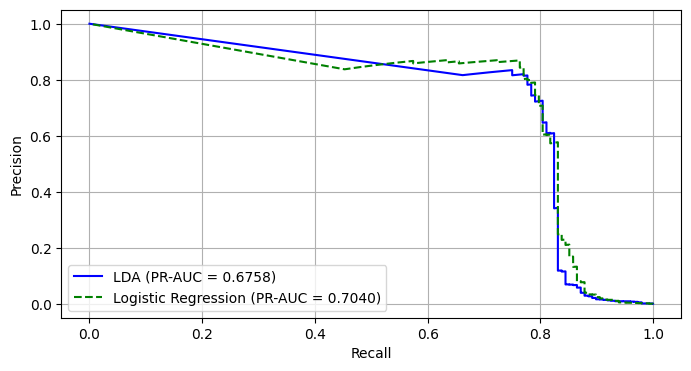

In [ ]:
# Calculate Precision-Recall curve data for Logistic Regression
precision_log_reg, recall_log_reg, _ = precision_recall_curve(y_test, y_pred_proba_log_reg)

# Calculate Precision-Recall curve data for LDA
precision_lda, recall_lda, _ = precision_recall_curve(y_test, y_pred_proba) # y_pred_proba comes from LDA

plt.figure(figsize=(8, 4))
plt.plot(recall_lda, precision_lda, 'b-', label=f'LDA (PR-AUC = {prauc_score_lda:.4f})')
plt.plot(recall_log_reg, precision_log_reg, 'g--', label=f'Logistic Regression (PR-AUC = {prauc_score_log_reg:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
# plt.title('Precision-Recall Curve Comparison: LDA vs. Logistic Regression')
plt.legend()
plt.grid()
plt.show()

## **Code block 5.11: Cross-validation results for the LDA and Logistic Regression models**

In [ ]:
# Store results for LDA and Logistic Regression
lda_prauc_scores = []
lda_precision_scores = []
lda_recall_scores = []
lda_f1_scores = []

log_reg_prauc_scores = []
log_reg_precision_scores = []
log_reg_recall_scores = []
log_reg_f1_scores = []

print(f"Performing {N_SPLITS}-Fold Stratified Cross-Validation...")

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Recalculate class weights for the current fold's training set
    fold_class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y_train_fold),
        y=y_train_fold)
    fold_weights_dict = dict(zip(np.unique(y_train_fold), fold_class_weights))

    # LDA Model Evaluation
    lda_fold = LinearDiscriminantAnalysis(n_components=1, solver='svd', priors=[0.5, 0.5])
    lda_fold.fit(X_train_fold, y_train_fold)
    y_pred_proba_lda_fold = lda_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_lda_fold = lda_fold.predict(X_test_fold)

    lda_prauc_scores.append(average_precision_score(y_test_fold, y_pred_proba_lda_fold))
    lda_precision_scores.append(precision_score(y_test_fold, y_pred_lda_fold))
    lda_recall_scores.append(recall_score(y_test_fold, y_pred_lda_fold))
    lda_f1_scores.append(f1_score(y_test_fold, y_pred_lda_fold))

    # Logistic Regression Model Evaluation
    log_reg_fold = LogisticRegression(solver='liblinear', class_weight=fold_weights_dict, random_state=42)
    log_reg_fold.fit(X_train_fold, y_train_fold)
    y_pred_proba_log_reg_fold = log_reg_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_log_reg_fold = log_reg_fold.predict(X_test_fold)

    log_reg_prauc_scores.append(average_precision_score(y_test_fold, y_pred_proba_log_reg_fold))
    log_reg_precision_scores.append(precision_score(y_test_fold, y_pred_log_reg_fold))
    log_reg_recall_scores.append(recall_score(y_test_fold, y_pred_log_reg_fold))
    log_reg_f1_scores.append(f1_score(y_test_fold, y_pred_log_reg_fold))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")

print("\nLDA (Linear Discriminant Analysis):")
print(f"  Mean PR-AUC: {np.mean(lda_prauc_scores):.4f} (Std: {np.std(lda_prauc_scores):.4f})")
print(f"  Mean Precision: {np.mean(lda_precision_scores):.4f} (Std: {np.std(lda_precision_scores):.4f})")
print(f"  Mean Recall: {np.mean(lda_recall_scores):.4f} (Std: {np.std(lda_recall_scores):.4f})")
print(f"  Mean F1-Score: {np.mean(lda_f1_scores):.4f} (Std: {np.std(lda_f1_scores):.4f})")

print("\nLogistic Regression:")
print(f"  Mean PR-AUC: {np.mean(log_reg_prauc_scores):.4f} (Std: {np.std(log_reg_prauc_scores):.4f})")
print(f"  Mean Precision: {np.mean(log_reg_precision_scores):.4f} (Std: {np.std(log_reg_precision_scores):.4f})")
print(f"  Mean Recall: {np.mean(log_reg_recall_scores):.4f} (Std: {np.std(log_reg_recall_scores):.4f})")
print(f"  Mean F1-Score: {np.mean(log_reg_f1_scores):.4f} (Std: {np.std(log_reg_f1_scores):.4f})")

Performing 5-Fold Stratified Cross-Validation...
Fold 1/5 complete.
Fold 2/5 complete.
Fold 3/5 complete.
Fold 4/5 complete.
Fold 5/5 complete.

LDA (Linear Discriminant Analysis):
  Mean PR-AUC: 0.7322 (Std: 0.0276)
  Mean Precision: 0.8636 (Std: 0.0214)
  Mean Recall: 0.7703 (Std: 0.0208)
  Mean F1-Score: 0.8142 (Std: 0.0183)

Logistic Regression:
  Mean PR-AUC: 0.7296 (Std: 0.0255)
  Mean Precision: 0.0651 (Std: 0.0033)
  Mean Recall: 0.9126 (Std: 0.0248)
  Mean F1-Score: 0.1214 (Std: 0.0057)


## **Logistic Regression hyperparameter grid search**

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']}

# Grid search with cross-validation
grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

## **Code block 5.12: Random Forest with default hyperparameter and Stratified k-Fold**

In [ ]:
rf_prauc = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_roc_auc = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Recalculate class weights for the current fold's training set
    fold_class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y_train_fold),
        y=y_train_fold)
    fold_weights_dict = dict(zip(np.unique(y_train_fold), fold_class_weights))

    # Evaluation
    rf_fold = RandomForestClassifier(class_weight=fold_weights_dict, random_state=42, n_jobs=-1)
    rf_fold.fit(X_train_fold, y_train_fold)
    y_pred_proba_rf_fold = rf_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_rf_fold = rf_fold.predict(X_test_fold)

    rf_prauc.append(average_precision_score(y_test_fold, y_pred_proba_rf_fold))
    rf_precision.append(precision_score(y_test_fold, y_pred_rf_fold))
    rf_recall.append(recall_score(y_test_fold, y_pred_rf_fold))
    rf_f1.append(f1_score(y_test_fold, y_pred_rf_fold))
    rf_roc_auc.append(roc_auc_score(y_test_fold, y_pred_proba_rf_fold))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")

print(f"  Mean PR-AUC: {np.mean(rf_prauc):.4f} (Std: {np.std(rf_prauc):.4f})")
print(f"  Mean Precision: {np.mean(rf_precision):.4f} (Std: {np.std(rf_precision):.4f})")
print(f"  Mean Recall: {np.mean(rf_recall):.4f} (Std: {np.std(rf_recall):.4f})")
print(f"  Mean F1-Score: {np.mean(rf_f1):.4f} (Std: {np.std(rf_f1):.4f})")
print(f"  Mean ROC-AUC: {np.mean(rf_roc_auc):.4f} (Std: {np.std(rf_roc_auc):.4f})")

Fold 1/5 complete.
Fold 2/5 complete.
Fold 3/5 complete.
Fold 4/5 complete.
Fold 5/5 complete.
  Mean PR-AUC: 0.8495 (Std: 0.0238)
  Mean Precision: 0.9619 (Std: 0.0249)
  Mean Recall: 0.7642 (Std: 0.0173)
  Mean F1-Score: 0.8516 (Std: 0.0186)
  Mean ROC-AUC: 0.9499 (Std: 0.0122)


In [ ]:
rf_prauc = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_roc_auc = []
rf_cv_logloss = []
rf_train_logloss = []

print("CROSS-VALIDATION WITH LOG LOSS")

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Recalculate class weights for the current fold's training set
    fold_class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y_train_fold),
        y=y_train_fold)
    fold_weights_dict = dict(zip(np.unique(y_train_fold), fold_class_weights))

    # Train Random Forest
    rf_fold = RandomForestClassifier(
        class_weight=fold_weights_dict,
        random_state=42,
        n_jobs=-1)
    rf_fold.fit(X_train_fold, y_train_fold)

    # Predictions on test set (CV)
    y_pred_proba_test = rf_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_test = rf_fold.predict(X_test_fold)

    # Predictions on training set (for overfitting check)
    y_pred_proba_train = rf_fold.predict_proba(X_train_fold)[:, 1]

    # Store metrics
    rf_prauc.append(average_precision_score(y_test_fold, y_pred_proba_test))
    rf_precision.append(precision_score(y_test_fold, y_pred_test))
    rf_recall.append(recall_score(y_test_fold, y_pred_test))
    rf_f1.append(f1_score(y_test_fold, y_pred_test))
    rf_roc_auc.append(roc_auc_score(y_test_fold, y_pred_proba_test))

    # Log loss (lower is better)
    rf_cv_logloss.append(log_loss(y_test_fold, y_pred_proba_test))
    rf_train_logloss.append(log_loss(y_train_fold, y_pred_proba_train))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")
    print(f"  CV Log Loss: {rf_cv_logloss[-1]:.4f} | Train Log Loss: {rf_train_logloss[-1]:.4f} | Gap: {rf_train_logloss[-1] - rf_cv_logloss[-1]:.4f}")

CROSS-VALIDATION WITH LOG LOSS
Fold 1/5 complete.
  CV Log Loss: 0.0099 | Train Log Loss: 0.0004 | Gap: -0.0095
Fold 2/5 complete.
  CV Log Loss: 0.0055 | Train Log Loss: 0.0004 | Gap: -0.0051
Fold 3/5 complete.
  CV Log Loss: 0.0062 | Train Log Loss: 0.0004 | Gap: -0.0059
Fold 4/5 complete.
  CV Log Loss: 0.0070 | Train Log Loss: 0.0004 | Gap: -0.0066
Fold 5/5 complete.
  CV Log Loss: 0.0076 | Train Log Loss: 0.0004 | Gap: -0.0072


## **CROSS-VALIDATION SUMMARY**

In [ ]:
cv_results = pd.DataFrame({
    'Metric': ['PR-AUC', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Log Loss', 'Train Log Loss'],
    'Mean': [
        np.mean(rf_prauc), np.mean(rf_precision),
        np.mean(rf_recall), np.mean(rf_f1),
        np.mean(rf_roc_auc), np.mean(rf_cv_logloss), np.mean(rf_train_logloss)],
    'Std': [
        np.std(rf_prauc), np.std(rf_precision),
        np.std(rf_recall), np.std(rf_f1),
        np.std(rf_roc_auc), np.std(rf_cv_logloss), np.std(rf_train_logloss)]})

print(cv_results.to_string(index=False))

print('\n')
print("OVERFITTING DETECTION (Log Loss Analysis)")

mean_train_logloss = np.mean(rf_train_logloss)
mean_cv_logloss = np.mean(rf_cv_logloss)
logloss_gap = mean_train_logloss - mean_cv_logloss

print(f"\nTraining Log Loss (mean): {mean_train_logloss:.4f}")
print(f"CV Log Loss (mean):       {mean_cv_logloss:.4f}")
print(f"Gap (Train - CV):         {logloss_gap:.4f}")

# Train on all training data (after initial split)
rf_full = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
rf_full.fit(X_train, y_train)

# Predictions
y_pred_proba_train_full = rf_full.predict_proba(X_train)[:, 1]
y_pred_proba_test_full = rf_full.predict_proba(X_test)[:, 1]
y_pred_test_full = rf_full.predict(X_test)

# Log loss
full_train_logloss = log_loss(y_train, y_pred_proba_train_full)
full_test_logloss = log_loss(y_test, y_pred_proba_test_full)
full_test_prauc = average_precision_score(y_test, y_pred_proba_test_full)
full_test_f1 = f1_score(y_test, y_pred_test_full)

print(f"\nFull Model Performance:")
print(f"  Training Log Loss: {full_train_logloss:.4f}")
print(f"  Test Log Loss:     {full_test_logloss:.4f}")
print(f"  Gap (Train - Test): {full_train_logloss - full_test_logloss:.4f}")
print(f"  Test PR-AUC:       {full_test_prauc:.4f}")
print(f"  Test F1-Score:     {full_test_f1:.4f}")

CROSS-VALIDATION SUMMARY
        Metric     Mean      Std
        PR-AUC 0.849493 0.023793
     Precision 0.961875 0.024874
        Recall 0.764234 0.017276
      F1-Score 0.851648 0.018636
       ROC-AUC 0.949885 0.012221
   CV Log Loss 0.007225 0.001483
Train Log Loss 0.000366 0.000009


OVERFITTING DETECTION (Log Loss Analysis)

Training Log Loss (mean): 0.0004
CV Log Loss (mean):       0.0072
Gap (Train - CV):         -0.0069

Full Model Performance:
  Training Log Loss: 0.0004
  Test Log Loss:     0.0092
  Gap (Train - Test): -0.0088
  Test PR-AUC:       0.8174
  Test F1-Score:     0.8203


## **Code Block 5.14: Random Forest hyperparameter grid search**

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]}

for key, value in param_grid.items():
    print(f"  {key}: {value}")

rf_tuned = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_tuned,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1).fit(X_train, y_train)

for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"\nBest cross-validation PR-AUC: {random_search.best_score_:.4f}")

rf_tuned = random_search.best_estimator_

# Predictions from tuned model
y_pred_tuned = rf_tuned.predict(X_test)
y_proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# Calculate metrics for the test set
test_f1 = f1_score(y_test, y_pred_tuned)
test_roc_auc = roc_auc_score(y_test, y_proba_tuned)
test_prauc = average_precision_score(y_test, y_proba_tuned)
test_precision = precision_score(y_test, y_pred_tuned)
test_recall = recall_score(y_test, y_pred_tuned)

print(f"\nTest Set Performance (Tuned Random Forest):")
print(f"  F1-Score:   {test_f1:.4f}")
print(f"  ROC-AUC:    {test_roc_auc:.4f}")
print(f"  PR-AUC:     {test_prauc:.4f}")
print(f"  Precision:  {test_precision:.4f}")
print(f"  Recall:     {test_recall:.4f}")

In [ ]:
xgb_prauc = []
xgb_precision = []
xgb_recall = []
xgb_f1 = []
xgb_roc_auc = []
xgb_cv_logloss = []
xgb_train_logloss = []

# Epsilon for probability clipping (avoid log(0))
EPSILON = 1e-15

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Calculate scale_pos_weight to handle class imbalance
    # scale_pos_weight = (number of negative samples) / (number of positive samples)
    n_neg = (y_train_fold == 0).sum()
    n_pos = (y_train_fold == 1).sum()
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

    # Initialize XGBoost classifier
    xgb_fold = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss')

    # Train the model
    xgb_fold.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
        verbose=False)

    # Predictions on test set (CV)
    y_pred_proba_test = xgb_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_test = xgb_fold.predict(X_test_fold)

    # Predictions on training set (for overfitting check)
    y_pred_proba_train = xgb_fold.predict_proba(X_train_fold)[:, 1]

    # Clip probabilities for numerical stability
    y_pred_proba_test = np.clip(y_pred_proba_test, EPSILON, 1 - EPSILON)
    y_pred_proba_train = np.clip(y_pred_proba_train, EPSILON, 1 - EPSILON)

    # Store metrics
    xgb_prauc.append(average_precision_score(y_test_fold, y_pred_proba_test))
    xgb_precision.append(precision_score(y_test_fold, y_pred_test))
    xgb_recall.append(recall_score(y_test_fold, y_pred_test))
    xgb_f1.append(f1_score(y_test_fold, y_pred_test))
    xgb_roc_auc.append(roc_auc_score(y_test_fold, y_pred_proba_test))
    xgb_cv_logloss.append(log_loss(y_test_fold, y_pred_proba_test))
    xgb_train_logloss.append(log_loss(y_train_fold, y_pred_proba_train))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")
    print(f"  CV Log Loss: {xgb_cv_logloss[-1]:.4f} | Train Log Loss: {xgb_train_logloss[-1]:.4f} | Gap: {xgb_train_logloss[-1] - xgb_cv_logloss[-1]:.4f}")

Fold 1/5 complete.
  CV Log Loss: 0.0036 | Train Log Loss: 0.0000 | Gap: -0.0036
Fold 2/5 complete.
  CV Log Loss: 0.0022 | Train Log Loss: 0.0000 | Gap: -0.0022
Fold 3/5 complete.
  CV Log Loss: 0.0028 | Train Log Loss: 0.0000 | Gap: -0.0027
Fold 4/5 complete.
  CV Log Loss: 0.0036 | Train Log Loss: 0.0000 | Gap: -0.0036
Fold 5/5 complete.
  CV Log Loss: 0.0041 | Train Log Loss: 0.0000 | Gap: -0.0041


In [ ]:
lgb_prauc = []
lgb_precision = []
lgb_recall = []
lgb_f1 = []
lgb_roc_auc = []
lgb_cv_logloss = []
lgb_train_logloss = []

# Epsilon for probability clipping (avoid log(0))
EPSILON = 1e-15

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Initialize LightGBM classifier
    lgb_fold = lgb.LGBMClassifier(
        is_unbalanced='True',
        random_state=42,
        n_jobs=-1,
        verbose=-1)

    # Train the model
    lgb_fold.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
        eval_metric='logloss',
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])

    # Predictions on test set (CV)
    y_pred_proba_test = lgb_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_test = lgb_fold.predict(X_test_fold)

    # Predictions on training set (for overfitting check)
    y_pred_proba_train = lgb_fold.predict_proba(X_train_fold)[:, 1]

    # Clip probabilities for numerical stability
    y_pred_proba_test = np.clip(y_pred_proba_test, EPSILON, 1 - EPSILON)
    y_pred_proba_train = np.clip(y_pred_proba_train, EPSILON, 1 - EPSILON)

    # Store metrics
    lgb_prauc.append(average_precision_score(y_test_fold, y_pred_proba_test))
    lgb_precision.append(precision_score(y_test_fold, y_pred_test))
    lgb_recall.append(recall_score(y_test_fold, y_pred_test))
    lgb_f1.append(f1_score(y_test_fold, y_pred_test))
    lgb_roc_auc.append(roc_auc_score(y_test_fold, y_pred_proba_test))
    lgb_cv_logloss.append(log_loss(y_test_fold, y_pred_proba_test))
    lgb_train_logloss.append(log_loss(y_train_fold, y_pred_proba_train))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")
    print(f"  CV Log Loss: {lgb_cv_logloss[-1]:.4f} | Train Log Loss: {lgb_train_logloss[-1]:.4f} | Gap: {lgb_train_logloss[-1] - lgb_cv_logloss[-1]:.4f}")

Fold 1/5 complete.
  CV Log Loss: 0.0129 | Train Log Loss: 0.0097 | Gap: -0.0033
Fold 2/5 complete.
  CV Log Loss: 0.0102 | Train Log Loss: 0.0100 | Gap: -0.0002
Fold 3/5 complete.
  CV Log Loss: 0.0109 | Train Log Loss: 0.0100 | Gap: -0.0010
Fold 4/5 complete.
  CV Log Loss: 0.0114 | Train Log Loss: 0.0099 | Gap: -0.0015
Fold 5/5 complete.
  CV Log Loss: 0.0137 | Train Log Loss: 0.0101 | Gap: -0.0036


# FEATURE IMPORTANCE FROM LIGHTGBM CROSS-VALIDATION


Fold 1/5 complete.
  CV Log Loss: 0.0129 | Train Log Loss: 0.0097 | Gap: -0.0033
Fold 2/5 complete.
  CV Log Loss: 0.0102 | Train Log Loss: 0.0100 | Gap: -0.0002
Fold 3/5 complete.
  CV Log Loss: 0.0109 | Train Log Loss: 0.0100 | Gap: -0.0010
Fold 4/5 complete.
  CV Log Loss: 0.0114 | Train Log Loss: 0.0099 | Gap: -0.0015
Fold 5/5 complete.
  CV Log Loss: 0.0137 | Train Log Loss: 0.0101 | Gap: -0.0036
FEATURE IMPORTANCE ACROSS ALL FOLDS:

Top 15 Features by GAIN importance (contribution to accuracy):
    Feature  Mean_Importance_Gain  Std_Importance_Gain
        V10          66837.737233         30360.642183
        V14          63348.478981           956.471397
         V7          18002.155172         29332.875862
        V27           4884.512426          3989.471491
        V12           4507.048047          2501.882648
        V26           3853.224489          1611.509893
        V16           3629.907707          2953.430766
Time_scaled           1851.217483          2783.572994

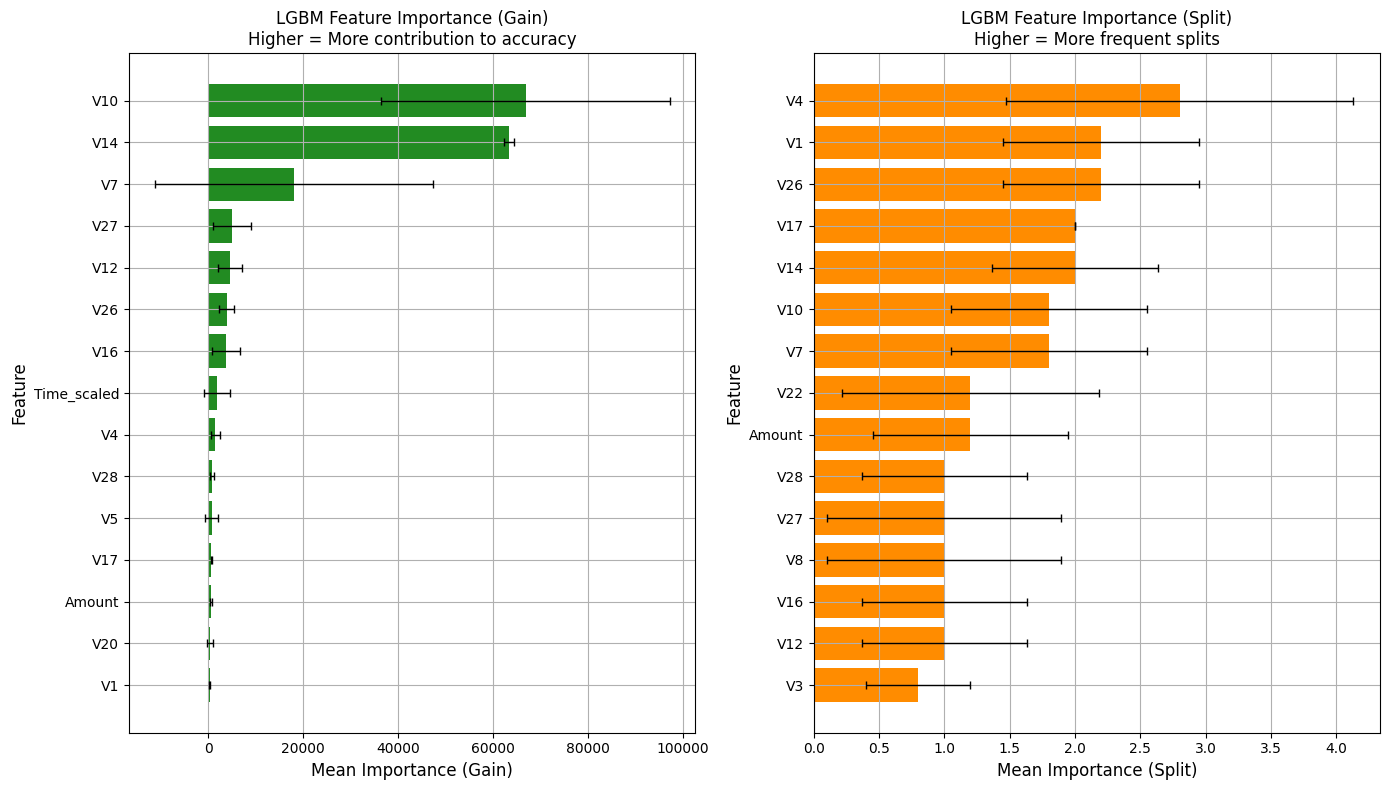



MOST CONSISTENT FEATURES ACROSS FOLDS (Lowest Std Dev):

Most consistent features by gain (lowest variance across folds):
      Feature  Mean_Importance_Gain  Std_Importance_Gain
Amount_scaled              4.391360             8.782720
          V24             16.863980            21.858288
           V8             25.519801            30.117424
           V2             17.230200            34.460400
          V23             18.377361            36.754721
           V6             21.898180            43.796360
          V13             46.230040            63.623563
          V19             52.860400            67.914110
          V18             50.967740            70.066484
          V17            581.676239            79.932659


FINAL MODEL FEATURE IMPORTANCE (Full Training Set):

Top 10 Features from Final Model (by Gain):
Feature  Gain_Importance  Split_Importance
     V8     7.589836e+08                87
     V7     3.120004e+08                74
    V26     2.332085e

In [ ]:
feature_importance_gain_all_folds = []
feature_importance_split_all_folds = []

# Existing cross-validation loop with feature importance collection
lgb_prauc = []
lgb_precision = []
lgb_recall = []
lgb_f1 = []
lgb_roc_auc = []
lgb_cv_logloss = []
lgb_train_logloss = []

# Epsilon for probability clipping (avoid log(0))
EPSILON = 1e-15

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Initialize LightGBM classifier
    lgb_fold = lgb.LGBMClassifier(
        is_unbalanced=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1)

    # Train the model
    lgb_fold.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
        eval_metric='logloss',
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])

    # Feature importance (gain = contribution to accuracy improvement)
    importance_gain = lgb_fold.booster_.feature_importance(importance_type='gain')
    importance_split = lgb_fold.booster_.feature_importance(importance_type='split')

    # Store for aggregation
    feature_importance_gain_all_folds.append(importance_gain)
    feature_importance_split_all_folds.append(importance_split)

    # Predictions on test set (CV)
    y_pred_proba_test = lgb_fold.predict_proba(X_test_fold)[:, 1]
    y_pred_test = lgb_fold.predict(X_test_fold)

    # Predictions on training set (for overfitting check)
    y_pred_proba_train = lgb_fold.predict_proba(X_train_fold)[:, 1]

    # Clip probabilities for numerical stability
    y_pred_proba_test = np.clip(y_pred_proba_test, EPSILON, 1 - EPSILON)
    y_pred_proba_train = np.clip(y_pred_proba_train, EPSILON, 1 - EPSILON)

    # Store metrics
    lgb_prauc.append(average_precision_score(y_test_fold, y_pred_proba_test))
    lgb_precision.append(precision_score(y_test_fold, y_pred_test))
    lgb_recall.append(recall_score(y_test_fold, y_pred_test))
    lgb_f1.append(f1_score(y_test_fold, y_pred_test))
    lgb_roc_auc.append(roc_auc_score(y_test_fold, y_pred_proba_test))
    lgb_cv_logloss.append(log_loss(y_test_fold, y_pred_proba_test))
    lgb_train_logloss.append(log_loss(y_train_fold, y_pred_proba_train))

    print(f"Fold {fold + 1}/{N_SPLITS} complete.")
    print(f"  CV Log Loss: {lgb_cv_logloss[-1]:.4f} | Train Log Loss: {lgb_train_logloss[-1]:.4f} | Gap: {lgb_train_logloss[-1] - lgb_cv_logloss[-1]:.4f}")

print("FEATURE IMPORTANCE ACROSS ALL FOLDS:")
feature_importance_gain_all_folds = np.array(feature_importance_gain_all_folds)
feature_importance_split_all_folds = np.array(feature_importance_split_all_folds)

# mean and standard deviation across folds
mean_importance_gain = np.mean(feature_importance_gain_all_folds, axis=0)
std_importance_gain = np.std(feature_importance_gain_all_folds, axis=0)
mean_importance_split = np.mean(feature_importance_split_all_folds, axis=0)
std_importance_split = np.std(feature_importance_split_all_folds, axis=0)

# DataFrame for gain importance
feature_importance_gain_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Importance_Gain': mean_importance_gain,
    'Std_Importance_Gain': std_importance_gain}).sort_values('Mean_Importance_Gain', ascending=False)

# Create DataFrame for split importance
feature_importance_split_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Importance_Split': mean_importance_split,
    'Std_Importance_Split': std_importance_split}).sort_values('Mean_Importance_Split', ascending=False)

print("\nTop 15 Features by GAIN importance (contribution to accuracy):")
print("="*60)
print(feature_importance_gain_df.head(15).to_string(index=False))

print("\n")
print("Top 15 Features by SPLIT importance (frequency of use):")
print(feature_importance_split_df.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Gain Importance (Top 15)
top_gain = feature_importance_gain_df.head(15)
axes[0].barh(top_gain['Feature'], top_gain['Mean_Importance_Gain'],
             xerr=top_gain['Std_Importance_Gain'],
             color='forestgreen', capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})
axes[0].set_xlabel('Mean Importance (Gain)', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].set_title('LGBM Feature Importance (Gain)\nHigher = More contribution to accuracy', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid()

# Split Importance (Top 15)
top_split = feature_importance_split_df.head(15)
axes[1].barh(top_split['Feature'], top_split['Mean_Importance_Split'],
             xerr=top_split['Std_Importance_Split'],
             color='darkorange', capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})
axes[1].set_xlabel('Mean Importance (Split)', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].set_title('LGBM Feature Importance (Split)\nHigher = More frequent splits', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid()

plt.tight_layout()
plt.show()

print("\n")
print("MOST CONSISTENT FEATURES ACROSS FOLDS (Lowest Std Dev):")

# For gain importance
consistent_gain = feature_importance_gain_df[
    feature_importance_gain_df['Mean_Importance_Gain'] > 0].sort_values('Std_Importance_Gain').head(10)

print("\nMost consistent features by gain (lowest variance across folds):")
print(consistent_gain[['Feature', 'Mean_Importance_Gain', 'Std_Importance_Gain']].to_string(index=False))

print("\n")
print("FINAL MODEL FEATURE IMPORTANCE (Full Training Set):")

# Train on full training set
lgb_final = lgb.LGBMClassifier(
    is_unbalanced=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1).fit(X_train, y_train)

# Feature importance from final model
final_importance_gain = lgb_final.booster_.feature_importance(importance_type='gain')
final_importance_split = lgb_final.booster_.feature_importance(importance_type='split')

final_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Gain_Importance': final_importance_gain,
    'Split_Importance': final_importance_split}).sort_values('Gain_Importance', ascending=False)

print("\nTop 10 Features from Final Model (by Gain):")
print(final_importance_df.head(10).to_string(index=False))

print("\n")
print("FEATURE IMPORTANCE SUMMARY REPORT:")

print(f"\nTotal features: {len(X.columns)}")
print(f"Features with non-zero gain importance: {(final_importance_gain > 0).sum()}")
print(f"Features with zero gain importance: {(final_importance_gain == 0).sum()}")

print(f"\nTop 5 features (Gain):")
for i, row in final_importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Gain_Importance']:.2f}")

print(f"\nBottom 5 features (Gain):")
for i, row in final_importance_df.tail(5).iterrows():
    print(f"  {len(final_importance_df)-i}. {row['Feature']}: {row['Gain_Importance']:.2f}")